# Импорты

In [199]:
# %pip install matplotlib
# %pip install pymatgen
# %pip install crystal_toolkit

In [200]:
import matplotlib.pyplot as plt
import pandas as pd

In [201]:
from pymatgen.core import Structure

from pymatgen.io.vasp.outputs import Outcar
from pymatgen.io.vasp.outputs import Vasprun
from pymatgen.io.vasp import Incar

from pymatgen.symmetry.bandstructure import HighSymmKpath
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer

from pymatgen.electronic_structure.core import Spin

In [202]:
import warnings

In [203]:
# Лицензия VASP прямо запрещает свободное распространение POTCAR-файлов
warnings.filterwarnings(
    "ignore",
    message="No POTCAR file with matching TITEL fields was found"
)

In [204]:
pd.set_option('display.float_format', lambda v: f'{v:g}')

In [205]:
# VASP_run_03
Ni_03_start_structure = Structure.from_file("Ni/POSCAR")
Al_03_start_structure = Structure.from_file("Al/POSCAR")
Ni3Al_03_start_structure = Structure.from_file("Ni3Al/POSCAR")

Ni_03_Outcar = Outcar("Ni/result/OUTCAR")
Al_03_Outcar = Outcar("Al/result/OUTCAR")
Ni3Al_03_Outcar = Outcar("Ni3Al/result/OUTCAR")

Ni_03_INCAR = Incar.from_file("Ni/INCAR")
Al_03_INCAR = Incar.from_file("Al/INCAR")
Ni3Al_03_INCAR = Incar.from_file("Ni3Al/INCAR")

Ni_03_vasprun = Vasprun("Ni/result/vasprun.xml")
Al_03_vasprun = Vasprun("Al/result/vasprun.xml")
Ni3Al_03_vasprun = Vasprun("Ni3Al/result/vasprun.xml")

In [206]:
# VASP_run_01 - для сравнения
Ni3Al_01_start_structure = Structure.from_file("../VASP_run_01/Ni3Al/POSCAR")
Ni3Al_01_optimized_structure = Structure.from_file("../VASP_run_01/Ni3Al/result/CONTCAR")
Ni3Al_01_INCAR = Incar.from_file("../VASP_run_01/Ni3Al/INCAR")
Ni3Al_01_Outcar = Outcar("../VASP_run_01/Ni3Al/result/OUTCAR")
Ni3Al_01_vasprun = Vasprun("../VASP_run_01/Ni3Al/result/vasprun.xml")

Ni_01_Outcar = Outcar("../VASP_run_01/Ni/result/OUTCAR")
Al_01_Outcar = Outcar("../VASP_run_01/Al/result/OUTCAR")
Ni_01_optimized_structure = Structure.from_file("../VASP_run_01/Ni/result/CONTCAR")
Al_01_optimized_structure = Structure.from_file("../VASP_run_01/Al/result/CONTCAR")
Ni_01_vasprun = Vasprun("../VASP_run_01/Ni/result/vasprun.xml")
Al_01_vasprun = Vasprun("../VASP_run_01/Al/result/vasprun.xml")

# Параметры расчета

In [207]:
df_incar = pd.DataFrame({
    'Ni': dict(Ni_03_INCAR),
    'Al': dict(Al_03_INCAR),
    'Ni3Al (VASP_run_03)': dict(Ni3Al_03_INCAR),
    'Ni3Al (VASP_run_01)': dict(Ni3Al_01_INCAR)
}).fillna('')

df_incar

,Ni,Al,Ni3Al (VASP_run_03),Ni3Al (VASP_run_01)
SYSTEM,Ni bulk fcc,Al bulk fcc,Ni3Al L12,Ni3Al L12
PREC,Accurate,Accurate,Accurate,Accurate
NCORE,4,4,4,4
LREAL,False,False,False,False
LWAVE,False,False,False,False
LASPH,True,True,True,True
ADDGRID,True,True,True,True
KSPACING,0.1,0.1,0.1,0.1
SYMPREC,1e-05,1e-05,1e-05,1e-05
ISYM,2,2,2,2


# Проверка сходимости электронного и ионного цикла

In [208]:
df_stats = pd.DataFrame([{**outcar.run_stats, 'System': name} for name, outcar in [('Ni', Ni_03_Outcar), ('Al', Al_03_Outcar), ('Ni3Al', Ni3Al_03_Outcar)]])
df_stats

,Average memory used (kb),Maximum memory used (kb),Elapsed time (sec),System time (sec),User time (sec),Total CPU time used (sec),cores,System
0,None,110152,132.939,18.598,110.833,129.431,24,Ni
1,None,76992,23.776,5.303,17.114,22.418,24,Al
2,None,134672,222.649,27.178,188.773,215.951,24,Ni3Al


> Все три расчёта завершились штатно и сошлись, а не остановились из-за ограничения по числу шагов (NSW). Во всех случаях стартовые структуры (fcc Ni, fcc Al, L1₂ Ni₃Al) уже были близки к равновесным, поэтому релаксация потребовала лишь двух итераций, и ионы практически не смещались.

## Электронный цикл

In [209]:
Ni_03_steps = Ni_03_vasprun.ionic_steps
Al_03_steps = Al_03_vasprun.ionic_steps
Ni3Al_03_steps = Ni3Al_03_vasprun.ionic_steps

In [210]:
data_03 = []
for name, steps in [('Ni', Ni_03_steps), ('Al', Al_03_steps), ('Ni3Al', Ni3Al_03_steps)]:
    es = steps[-1]['electronic_steps']
    for i in range(1, len(es)):
        d = abs(es[i]['e_fr_energy'] - es[i-1]['e_fr_energy'])
        data_03.append((name, i, d))

df_03_delta_e = pd.DataFrame(data_03, columns=['Система', 'Итерация', '|ΔE| (эВ)'])
df_03_delta_e.style.hide(axis='index').format({'|ΔE| (эВ)': '{:.10f}'})

Система,Итерация,|ΔE| (эВ)
Ni,1,246.3319304400
Ni,2,8.8501742900
Ni,3,0.0582408000
Ni,4,0.0001419400
Ni,5,2.6856436900
Ni,6,1.2367743400
Ni,7,0.0501916800
Ni,8,0.0146452300
Ni,9,0.0001680400
Ni,10,0.0000161900


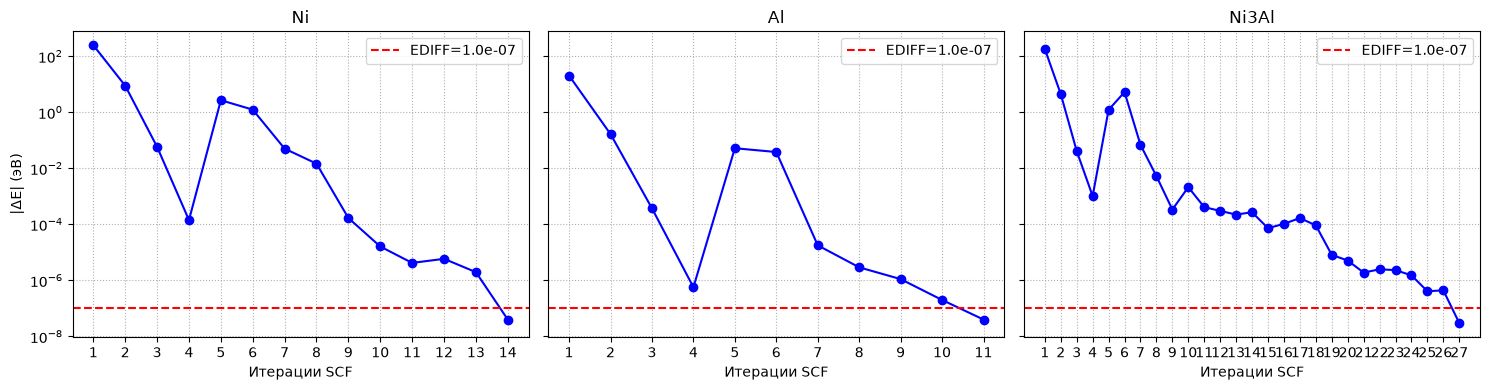

In [211]:
EDIFF_03 = Ni_03_INCAR.get('EDIFF')

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, name in zip(axes, ['Ni', 'Al', 'Ni3Al']):
    sub = df_03_delta_e[df_03_delta_e['Система'] == name]
    ax.plot(sub['Итерация'], sub['|ΔE| (эВ)'], 'o-', color='b')
    ax.axhline(EDIFF_03, color='r', linestyle='--', label=f'EDIFF={EDIFF_03:.1e}')
    ax.set_yscale('log')    
    ax.set_xlabel('Итерации SCF')
    ax.set_title(name)
    ax.grid(linestyle=':')
    ax.legend()
    max_iter = sub['Итерация'].max()
    ax.set_xticks(range(1, max_iter + 1))

axes[0].set_ylabel('|ΔE| (эВ)')

plt.tight_layout()
plt.show()

## Ионный цикл

In [212]:
data_03_ion_forces = []
for name, steps in [('Ni', Ni_03_steps), ('Al', Al_03_steps), ('Ni3Al', Ni3Al_03_steps)]:
    for i, step in enumerate(steps):
        forces = step['forces']
        max_force = max(abs(f) for atom in forces for f in atom)
        data_03_ion_forces.append({'Система': name, 'Ионный шаг': i, '|F_max| (эВ/Å)': max_force})

df_03_ion_forces = pd.DataFrame(data_03_ion_forces)
df_03_ion_forces

,Система,Ионный шаг,|F_max| (эВ/Å)
0,Ni,0,0
1,Al,0,0
2,Ni3Al,0,0


> **Примечание по ионной сходимости**     
> Для VASP_run_03 (ISIF=2) был выполнен только начальный SCF-расчёт (шаг 0), релаксация фактически не запускалась (или завершилась сразу, поскольку силы нулевые).

# Кристаллографические парамеры

In [213]:
# Начальный параметр решетки
Ni_03_a = Ni_03_start_structure.lattice.a
Al_03_a = Al_03_start_structure.lattice.a
Ni3Al_03_a = Ni3Al_03_start_structure.lattice.a

# Начальный объем
Ni_03_volume = Ni_03_start_structure.volume
Al_03_volume = Al_03_start_structure.volume
Ni3Al_03_volume = Ni3Al_03_start_structure.volume

# Пространственная группа
Ni_03_Space_Group = SpacegroupAnalyzer(Ni_03_start_structure, 0.1).get_space_group_symbol()
Al_03_Space_Group = SpacegroupAnalyzer(Al_03_start_structure, 0.1).get_space_group_symbol()
Ni3Al_03_Space_Group = SpacegroupAnalyzer(Ni3Al_03_start_structure, 0.1).get_space_group_symbol()


In [214]:
# Параметры решётки из VASP_run_01
Ni_a_opt_01 = Ni_01_optimized_structure.lattice.a
Al_a_opt_01 = Al_01_optimized_structure.lattice.a
Ni3Al_a_opt_01 = Ni3Al_01_optimized_structure.lattice.a

# Объем из VASP_run_01
Ni_volume_01 = Ni_01_optimized_structure.volume
Al_volume_01 = Al_01_optimized_structure.volume
Ni3Al_volume_01 = Ni3Al_01_optimized_structure.volume

In [215]:
data_crystal_03 = {
    'Система': ['Ni', 'Al', 'Ni3Al'],
    'Группа': [Ni_03_Space_Group, Al_03_Space_Group, Ni3Al_03_Space_Group],
    'a старт. (Å)': [Ni_03_a, Al_03_a, Ni3Al_03_a],
    '(VASP_run_01) a опт. (Å)': [Ni_a_opt_01, Al_a_opt_01, Ni3Al_a_opt_01],
    'V старт. (Å³)': [Ni_03_volume, Al_03_volume, Ni3Al_03_volume],
    '(VASP_run_01) V опт. (Å³)': [Ni_volume_01, Al_volume_01, Ni3Al_volume_01],
}

df_crystal_03 = pd.DataFrame(data_crystal_03)
df_crystal_03

,Система,Группа,a старт. (Å),(VASP_run_01) a опт. (Å),V старт. (Å³),(VASP_run_01) V опт. (Å³)
0,Ni,Fm-3m,3.52,3.52375,43.6142,43.7539
1,Al,Fm-3m,4.05,4.03865,66.4301,65.8733
2,Ni3Al,Pm-3m,3.57,3.5689,45.4993,45.4574


# Магнитный момент

In [216]:
Al_03_total_mag = Al_03_Outcar.total_mag
Al_03_total_mag # None

In [217]:
Ni_03_total_mag = Ni_03_Outcar.total_mag
print("Ni:", Ni_03_total_mag, "μ_B")

Ni: 2.504001 μ_B



**из INCAR для Ni:**
```VASP
ISPIN=2
MAGMOM=4*0.6
```

Получив для чистого никеля `total_mag = 2.504001 µ_B` (при стартовом `MAGMOM = 4×0.6 = 2.4 µ_B`), можно заключить, что система не только сохранила заданную намагниченность, но и увеличила её за счёт обменного взаимодействия. Финальное значение близко к экспериментальному (∼0.6 µ_B на атом Ni - [DOI:10.1103/PhysRev.138.A755](https://journals.aps.org/pr/abstract/10.1103/PhysRev.138.A755)), что подтверждает устойчивость ферромагнитного состояния в чистом Ni.

In [218]:
Ni3Al_03_total_mag = Ni3Al_03_Outcar.total_mag
print("Ni3Al:", Ni3Al_03_total_mag, "μ_B")

Ni3Al: 0.0011988 μ_B


**из INCAR для Ni3Al:**
```VASP
ISPIN=2
MAGMOM=0.0 3*0.2
```

Несмотря на то, что в INCAR был задан ISPIN=2 и начальные магнитные моменты `MAGMOM = 0.0 3*0.2` (для каждого атома Ni – 0.2 $μ_B$), итоговая суммарная намагниченность системы оказалась практически равной нулю (0.0011988 µ_B). Это свидетельствует о том, что спонтанная спиновая поляризация в данной структуре отсутствует – расчёт привёл к немагнитному состоянию.

Такое поведение согласуется с литературными данными ([DOI:10.1016/j.intermet.2006.08.010](https://www.sciencedirect.com/science/article/abs/pii/S0966979506002548?via%3Dihub)) для объёмного Ni₃Al со структурой L1₂ – он действительно является слабомагнитным или парамагнитным при комнатных условиях.

In [219]:
Ni3Al_03_Outcar.magnetization

({'s': 0.0, 'p': -0.0, 'd': 0.0, 'tot': -0.0},
 {'s': -0.0, 'p': -0.0, 'd': 0.001, 'tot': 0.001},
 {'s': -0.0, 'p': -0.0, 'd': 0.001, 'tot': 0.001},
 {'s': -0.0, 'p': -0.0, 'd': 0.001, 'tot': 0.001})

> Все значения практически равны нулю. Это означает, что на атомах Ni и Al не возникает спонтанной спиновой поляризации – локальные магнитные моменты отсутствуют.
>
> Важно отметить, что сумма локальных моментов не обязана в точности равняться полному моменту, поскольку локальные моменты интегрируются только внутри сфер радиуса `RWIGS`, а часть спиновой плотности может находиться в межатомных областях. Однако в данном случае обе величины практически нулевые, что подтверждает немагнитный характер системы.
>
> Таким образом, добавление `LORBIT = 11` позволило убедиться в отсутствии локальных магнитных моментов в системе Ni₃Al.

P.S. отрицательные нули `-0.0` являются артефактами округления с плавающей точкой

# Полные энергии и энтальпия образования Ni3Al

In [220]:
# Полные энергии
TOTEN_Ni_03 = Ni_03_Outcar.final_energy
TOTEN_Al_03 = Al_03_Outcar.final_energy
TOTEN_Ni3Al_03 = Ni3Al_03_Outcar.final_energy

print("Ni:", TOTEN_Ni_03, "эВ")
print("Al:", TOTEN_Al_03, "эВ")
print("Ni3Al:", TOTEN_Ni3Al_03, "эВ")

Ni: -22.2895925 эВ
Al: -14.98398113 эВ
Ni3Al: -22.19658512 эВ


In [221]:
# Изменение энтальпии образования, выраженное в электрон-вольтах на одну формульную единицу
dH_form_ev_per_fu = TOTEN_Ni3Al_03 - (0.75*TOTEN_Ni_03+0.25*TOTEN_Al_03)

# Изменение энтальпии образования, выраженное в килоджоулях на моль формульных единиц
dH_form_kJ_per_mol_fu = dH_form_ev_per_fu*96.485

# Изменение энтальпии образования, выраженное в килоджоулях на моль атомов
dH_form_kJ_per_mol_atom = dH_form_kJ_per_mol_fu / 4

print(dH_form_ev_per_fu, "эВ")
print(dH_form_kJ_per_mol_fu, "кДж/моль формульных единиц")
print(dH_form_kJ_per_mol_atom, "кДж/моль атомов")

-1.733395462499999 эВ
-167.2466611993124 кДж/моль формульных единиц
-41.8116652998281 кДж/моль атомов


# K-точки

In [222]:
# Кол-во K-точек
Ni_03_N_KPOINTS = len(Ni_03_vasprun.actual_kpoints)
Al_03_N_KPOINTS = len(Al_03_vasprun.actual_kpoints)
Ni3Al_03_N_KPOINTS = len(Ni3Al_03_vasprun.actual_kpoints)

# Координаты первой k-точки по направлению
Ni_03_kx, Ni_03_ky, Ni_03_kz = Ni_03_vasprun.kpoints.kpts[0]
Al_03_kx, Al_03_ky, Al_03_kz = Al_03_vasprun.kpoints.kpts[0]
Ni3Al_03_kx, Ni3Al_03_ky, Ni3Al_03_kz = Ni3Al_03_vasprun.kpoints.kpts[0]

# K-cетка
Ni_03_kmesh = f"{Ni_03_kx}×{Ni_03_ky}×{Ni_03_kz}"
Al_03_kmesh = f"{Al_03_kx}×{Al_03_ky}×{Al_03_kz}"
Ni3Al_03_kmesh = f"{Ni3Al_03_kx}×{Ni3Al_03_ky}×{Ni3Al_03_kz}"

# Приводим к примитивной ячейке для корректного получения точек высокой симметрии (зона Бриллюэна задана для примитивной ячейки)
prim_Ni_03 = SpacegroupAnalyzer(Ni_03_start_structure).get_primitive_standard_structure()
prim_Al_03 = SpacegroupAnalyzer(Al_03_start_structure).get_primitive_standard_structure()
prim_Ni3Al_03 = SpacegroupAnalyzer(Ni3Al_03_start_structure).get_primitive_standard_structure()

# K-точки высокой симметрии
Ni_03_hs_points = ', '.join(HighSymmKpath(prim_Ni_03).kpath['kpoints'].keys())
Al_03_hs_points = ', '.join(HighSymmKpath(prim_Al_03).kpath['kpoints'].keys())
Ni3Al_03_hs_points = ', '.join(HighSymmKpath(prim_Ni3Al_03).kpath['kpoints'].keys())

In [223]:
data_kpoints_03 = {
    'Система': ['Ni', 'Al', 'Ni3Al'],
    'N k-точек': [Ni_03_N_KPOINTS, Al_03_N_KPOINTS, Ni3Al_03_N_KPOINTS],
    'K-сетка': [Ni_03_kmesh, Al_03_kmesh, Ni3Al_03_kmesh],
    'Высокосимм. точки': [Ni_03_hs_points, Al_03_hs_points, Ni3Al_03_hs_points],
}

df_kpoints_03 = pd.DataFrame(data_kpoints_03)
df_kpoints_03

,Система,N k-точек,K-сетка,Высокосимм. точки
0,Ni,220,18×18×18,"\Gamma, K, L, U, W, X"
1,Al,165,16×16×16,"\Gamma, K, L, U, W, X"
2,Ni3Al,220,18×18×18,"\Gamma, X, R, M"


# Плотность состояний (DOS)

In [224]:
# [VASP_run_03] Полная плотность состояний
Ni_03_complete_dos = Ni_03_vasprun.complete_dos
Al_03_complete_dos = Al_03_vasprun.complete_dos
Ni3Al_03_complete_dos = Ni3Al_03_vasprun.complete_dos

# [VASP_run_03] Энергетическая сетка для DOS (эВ)
Ni_03_complete_dos_energy = Ni_03_complete_dos.energies
Al_03_complete_dos_energy = Al_03_complete_dos.energies
Ni3Al_03_complete_dos_energy = Ni3Al_03_complete_dos.energies

# [VASP_run_03] Суммарная плотность состояний (states/eV)
Ni_03_complete_dos_densities = sum(Ni_03_complete_dos.densities.values())
Al_03_complete_dos_densities = sum(Al_03_complete_dos.densities.values())
Ni3Al_03_complete_dos_densities = sum(Ni3Al_03_complete_dos.densities.values())

# [VASP_run_03] Энергия Ферми (эВ)
Ni_03_efermi = Ni_03_vasprun.complete_dos.efermi
Al_03_efermi = Al_03_vasprun.complete_dos.efermi
Ni3Al_03_efermi = Ni3Al_03_vasprun.complete_dos.efermi

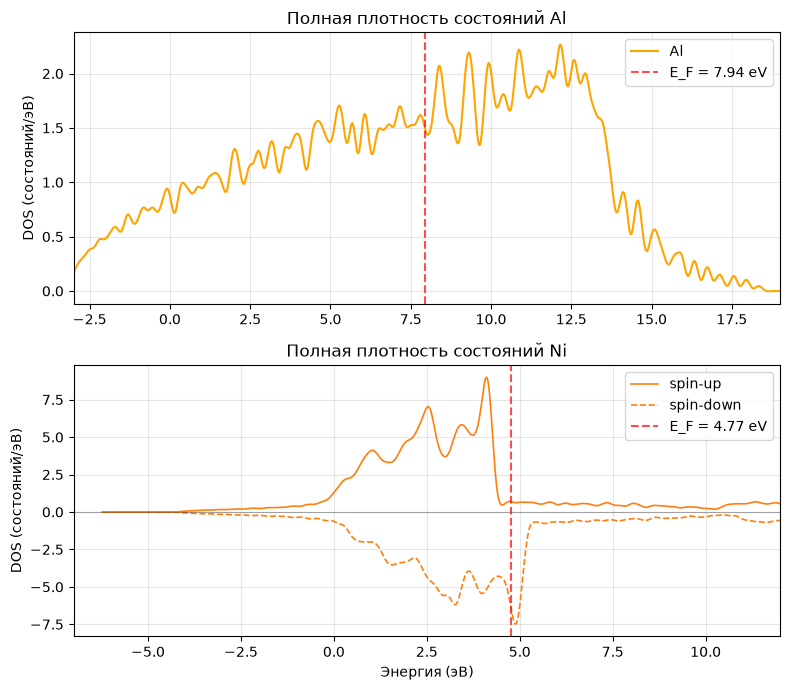

In [225]:
fig, axes = plt.subplots(2, 1, figsize=(8, 7))

# TDOS Al (неспин-поляризован)
axes[0].plot(Al_03_complete_dos_energy, Al_03_complete_dos_densities, color='orange', label='Al')
axes[0].axvline(Al_03_efermi, color='r', linestyle='--', alpha=0.7, linewidth=1.5, label=f'E_F = {Al_03_efermi:.2f} eV')
axes[0].set_xlim(-3, 19)
axes[0].set_ylabel('DOS (состояний/эВ)')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_title('Полная плотность состояний Al')

# TDOS Ni (спин-поляризован)
axes[1].plot(Ni_03_complete_dos_energy, Ni_03_complete_dos.densities[Spin.up], '-', label='spin-up', color='tab:orange', linewidth=1.2)
axes[1].plot(Ni_03_complete_dos_energy, -Ni_03_complete_dos.densities[Spin.down], '--', label='spin-down', color='tab:orange', linewidth=1.2)
axes[1].axhline(0, color='k', linestyle='-', alpha=0.3, linewidth=0.8)
axes[1].axvline(Ni_03_efermi, color='r', linestyle='--', alpha=0.7, linewidth=1.5, label=f'E_F = {Ni_03_efermi:.2f} eV')
axes[1].set_xlim(-7, 12)
axes[1].set_xlabel('Энергия (эВ)')
axes[1].set_ylabel('DOS (состояний/эВ)')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_title('Полная плотность состояний Ni')

plt.tight_layout()
plt.show()

## Проектированный DOS (LORBIT=11)

In [226]:
# Извлекаем проектированную DOS по элементам и получаем список элементов
Ni3Al_03_pdos_element_dos = Ni3Al_03_complete_dos.get_element_dos()
Ni3Al_03_elements = list(Ni3Al_03_pdos_element_dos.keys())

# PDOS для Al и Ni
Ni3Al_03_pdos_Al = Ni3Al_03_pdos_element_dos[Ni3Al_03_elements[0]]
Ni3Al_03_pdos_Ni = Ni3Al_03_pdos_element_dos[Ni3Al_03_elements[1]]

# Спиновые компоненты плотностей состояний
dens_up_total = Ni3Al_03_complete_dos.get_densities(Spin.up)
dens_down_total = Ni3Al_03_complete_dos.get_densities(Spin.down)

dens_up_Al = Ni3Al_03_pdos_Al.get_densities(Spin.up)
dens_down_Al = Ni3Al_03_pdos_Al.get_densities(Spin.down)

dens_up_Ni = Ni3Al_03_pdos_Ni.get_densities(Spin.up)
dens_down_Ni = Ni3Al_03_pdos_Ni.get_densities(Spin.down)

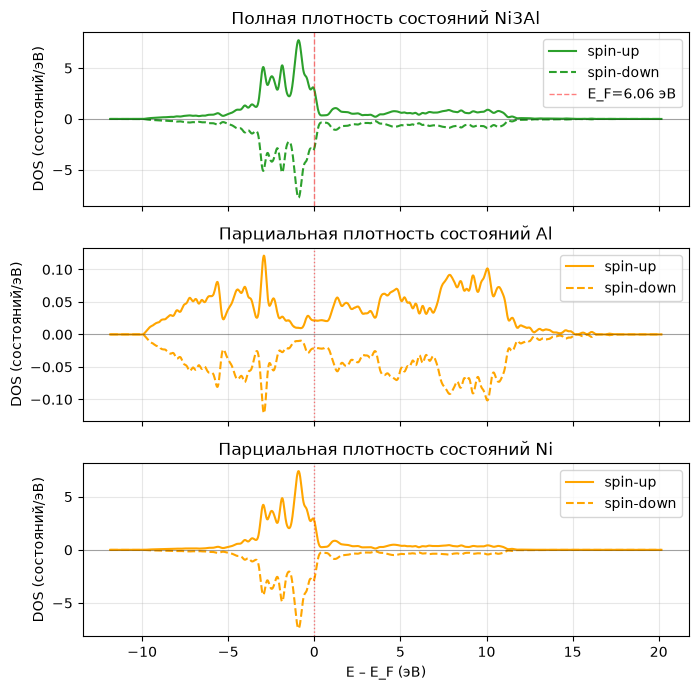

In [227]:
# Сдвиг энергии относительно уровня Ферми
e_total = Ni3Al_03_complete_dos_energy - Ni3Al_03_efermi
e_al = Ni3Al_03_pdos_Al.energies - Ni3Al_03_efermi
e_ni = Ni3Al_03_pdos_Ni.energies - Ni3Al_03_efermi

fig, axes = plt.subplots(3, 1, figsize=(7, 7), sharex=True)

# TDOS Ni3Al
axes[0].plot(e_total, dens_up_total, '-', label='spin-up', color='tab:green', linewidth=1.5)
axes[0].plot(e_total, -dens_down_total, '--', label='spin-down', color='tab:green', linewidth=1.5)
axes[0].axhline(0, color='k', linestyle='-', alpha=0.3, linewidth=0.8)
axes[0].axvline(0, color='r', linestyle='--', alpha=0.5, linewidth=1, label=f'E_F={Ni3Al_03_efermi:.2f} эВ')
axes[0].set_ylabel('DOS (состояний/эВ)')
axes[0].set_title('Полная плотность состояний Ni3Al')
axes[0].grid(alpha=0.3)
axes[0].legend()

# PDOS Al
axes[1].plot(e_al, dens_up_Al, '-', label='spin-up', color='orange', linewidth=1.5)
axes[1].plot(e_al, -dens_down_Al, '--', label='spin-down', color='orange', linewidth=1.5)
axes[1].axhline(0, color='k', linestyle='-', alpha=0.3, linewidth=0.8)
axes[1].axvline(0, color='r', linestyle=':', alpha=0.5, linewidth=1)
axes[1].set_ylabel('DOS (состояний/эВ)')
axes[1].set_title('Парциальная плотность состояний Al')
axes[1].grid(alpha=0.3)
axes[1].legend()

# PDOS Ni
axes[2].plot(e_ni, dens_up_Ni, '-', label='spin-up', color='orange', linewidth=1.5)
axes[2].plot(e_ni, -dens_down_Ni, '--', label='spin-down', color='orange', linewidth=1.5)
axes[2].axhline(0, color='k', linestyle='-', alpha=0.3, linewidth=0.8)
axes[2].axvline(0, color='r', linestyle=':', alpha=0.5, linewidth=1)
axes[2].set_xlabel('E – E_F (эВ)')
axes[2].set_ylabel('DOS (состояний/эВ)')
axes[2].set_title('Парциальная плотность состояний Ni')
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

# Сводная таблица

In [228]:
df_summary = pd.DataFrame([
    {'Система': 'Ni', 'E_F (эВ)': Ni_03_efermi, 'Магн. момент (μB)': Ni_03_total_mag, 'Полная энергия (эВ)': TOTEN_Ni_03, 'ΔH_обр (кДж/моль атомов)': float('nan')},
    {'Система': 'Al', 'E_F (эВ)': Al_03_efermi, 'Магн. момент (μB)': Al_03_total_mag, 'Полная энергия (эВ)': TOTEN_Al_03, 'ΔH_обр (кДж/моль атомов)': float('nan')},
    {'Система': 'Ni3Al', 'E_F (эВ)': Ni3Al_03_efermi, 'Магн. момент (μB)': Ni3Al_03_total_mag, 'Полная энергия (эВ)': TOTEN_Ni3Al_03, 'ΔH_обр (кДж/моль атомов)': dH_form_kJ_per_mol_atom},
])

df_summary = df_summary.merge(df_crystal_03)
df_summary = df_summary.merge(df_kpoints_03)
df_summary

,Система,E_F (эВ),Магн. момент (μB),Полная энергия (эВ),ΔH_обр (кДж/моль атомов),Группа,a старт. (Å),(VASP_run_01) a опт. (Å),V старт. (Å³),(VASP_run_01) V опт. (Å³),N k-точек,K-сетка,Высокосимм. точки
0,Ni,4.77304,2.504,-22.2896,NaN,Fm-3m,3.52,3.52375,43.6142,43.7539,220,18×18×18,"\Gamma, K, L, U, W, X"
1,Al,7.9392,NaN,-14.984,NaN,Fm-3m,4.05,4.03865,66.4301,65.8733,165,16×16×16,"\Gamma, K, L, U, W, X"
2,Ni3Al,6.06291,0.0011988,-22.1966,-41.8117,Pm-3m,3.57,3.5689,45.4993,45.4574,220,18×18×18,"\Gamma, X, R, M"


# Сравнение ISIF=2 (run_03) и ISIF=3 (run_01)

In [229]:
# Полные энергии из VASP_run_01
TOTEN_Ni_01 = Ni_01_Outcar.final_energy
TOTEN_Al_01 = Al_01_Outcar.final_energy
TOTEN_Ni3Al_01 = Ni3Al_01_Outcar.final_energy

# Магнитные моменты из VASP_run_01
Ni_mag_01 = Ni_01_Outcar.total_mag
Al_mag_01 = Al_01_Outcar.total_mag
Ni3Al_mag_01 = Ni3Al_01_Outcar.total_mag

# Энергии Ферми из VASP_run_01
Ni_01_efermi = Ni_01_Outcar.efermi
Al_01_efermi = Al_01_Outcar.efermi
Ni3Al_01_efermi = Ni3Al_01_Outcar.efermi

# Энтальпия образования (VASP_run_01), кДж/моль атомов
dH_form_ev_per_fu_01 = TOTEN_Ni3Al_01 - (0.75 * TOTEN_Ni_01 + 0.25 * TOTEN_Al_01)
dH_form_kJ_per_mol_fu_01 = dH_form_ev_per_fu_01 * 96.485
dH_form_kJ_per_mol_atom_01 = dH_form_kJ_per_mol_fu_01 / 4

In [230]:
comparison_data = {
    'Система': ['Ni', 'Al', 'Ni3Al'],
    'E (эВ) (VASP_run_01)': [TOTEN_Ni_01, TOTEN_Al_01, TOTEN_Ni3Al_01],
    'E (эВ) (VASP_run_03)': [TOTEN_Ni_03, TOTEN_Al_03, TOTEN_Ni3Al_03],
    'ΔE (эВ)': [TOTEN_Ni_01 - TOTEN_Ni_03, TOTEN_Al_01 - TOTEN_Al_03, TOTEN_Ni3Al_01 - TOTEN_Ni3Al_03],
    'E_F (эВ) (VASP_run_01)': [Ni_01_efermi, Al_01_efermi, Ni3Al_01_efermi],
    'E_F (эВ) (VASP_run_03)': [Ni_03_efermi, Al_03_efermi, Ni3Al_03_efermi],
    'ΔE_F (эВ)': [Ni_01_efermi - Ni_03_efermi, Al_01_efermi - Al_03_efermi, Ni3Al_01_efermi - Ni3Al_03_efermi],
    'a опт. (Å) (VASP_run_01)': [Ni_a_opt_01, Al_a_opt_01, Ni3Al_a_opt_01],
    'a старт. (Å) (VASP_run_03)': [Ni_03_a, Al_03_a, Ni3Al_03_a],
    'Δa (Å)': [Ni_a_opt_01 - Ni_03_a, Al_a_opt_01 - Al_03_a, Ni3Al_a_opt_01 - Ni3Al_03_a],
    'Магн. момент (VASP_run_01)': [Ni_mag_01, Al_mag_01, Ni3Al_mag_01],
    'Магн. момент (VASP_run_03)': [Ni_03_total_mag, Al_03_total_mag, Ni3Al_03_total_mag],
    'ΔM (μB)': [Ni_mag_01 - Ni_03_total_mag, 0 , Ni3Al_mag_01 - Ni3Al_03_total_mag],
    'ΔH_обр (кДж/моль атомов) (VASP_run_01)': [float('nan'), float('nan'), dH_form_kJ_per_mol_atom_01],
    'ΔH_обр (кДж/моль атомов) (VASP_run_03)': [float('nan'), float('nan'), dH_form_kJ_per_mol_atom],
    'Δ(ΔH_обр) (кДж/моль атомов)': [float('nan'), float('nan'), dH_form_kJ_per_mol_atom_01 - dH_form_kJ_per_mol_atom],
}
df_compare = pd.DataFrame(comparison_data)
df_compare

,Система,E (эВ) (VASP_run_01),E (эВ) (VASP_run_03),ΔE (эВ),E_F (эВ) (VASP_run_01),E_F (эВ) (VASP_run_03),ΔE_F (эВ),a опт. (Å) (VASP_run_01),a старт. (Å) (VASP_run_03),Δa (Å),Магн. момент (VASP_run_01),Магн. момент (VASP_run_03),ΔM (μB),ΔH_обр (кДж/моль атомов) (VASP_run_01),ΔH_обр (кДж/моль атомов) (VASP_run_03),Δ(ΔH_обр) (кДж/моль атомов)
0,Ni,-22.2899,-22.2896,-0.00026097,4.7427,4.77304,-0.0303355,3.52375,3.52,0.00375489,2.50774,2.504,0.0037393,NaN,NaN,NaN
1,Al,-14.9852,-14.984,-0.00118296,7.9392,7.9392,-3.32e-06,4.03865,4.05,-0.0113479,NaN,NaN,0,NaN,NaN,NaN
2,Ni3Al,-22.1966,-22.1966,-1.768e-05,6.0722,6.06291,0.00929311,3.5689,3.57,-0.00109535,0.0001541,0.0011988,-0.0010447,-41.8002,-41.8117,0.0114283


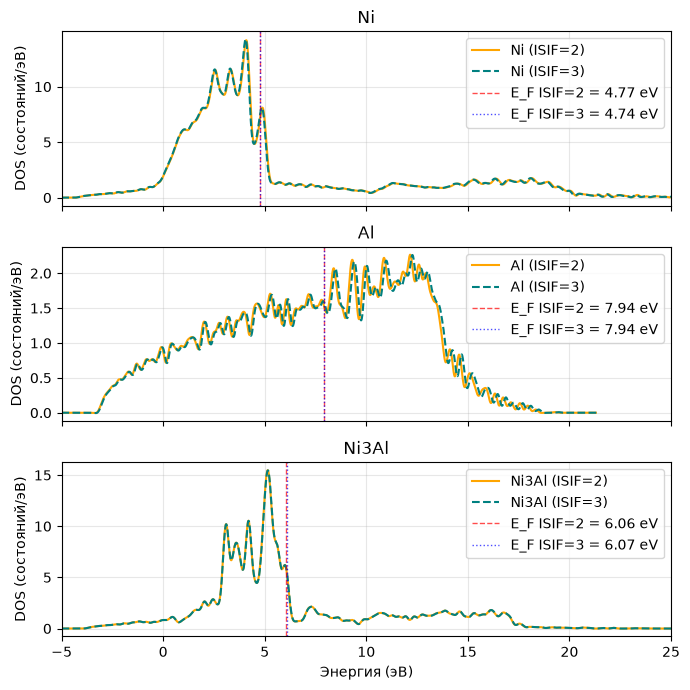

In [231]:
VASP_03 = [(Ni_03_vasprun, Ni_03_efermi, 'Ni'),
         (Al_03_vasprun, Al_03_efermi, 'Al'),
         (Ni3Al_03_vasprun, Ni3Al_03_efermi, 'Ni3Al')]

VASP_01 = [(Ni_01_vasprun, Ni_01_efermi, 'Ni'),
         (Al_01_vasprun, Al_01_efermi, 'Al'),
         (Ni3Al_01_vasprun, Ni3Al_01_efermi, 'Ni3Al')]

fig, axes = plt.subplots(3, 1, figsize=(7, 7), sharex=True)

for i, ((v03, ef03, label), (v01, ef01, _)) in enumerate(zip(VASP_03, VASP_01)):
    dos03 = sum(v03.complete_dos.densities.values())
    dos01 = sum(v01.complete_dos.densities.values())
    axes[i].plot(v03.complete_dos.energies, dos03, color='orange', label=f'{label} (ISIF=2)')
    axes[i].plot(v01.complete_dos.energies, dos01, color='teal', linestyle='--', label=f'{label} (ISIF=3)')
    axes[i].axvline(ef03, color='r', linestyle='--', alpha=0.7, linewidth=1, label=f'E_F ISIF=2 = {ef03:.2f} eV')
    axes[i].axvline(ef01, color='b', linestyle=':', alpha=0.7, linewidth=1, label=f'E_F ISIF=3 = {ef01:.2f} eV')
    axes[i].set_ylabel('DOS (состояний/эВ)')
    axes[i].legend()
    axes[i].grid(alpha=0.3)
    axes[i].set_title(label)

axes[2].set_xlabel('Энергия (эВ)')

plt.xlim(-5, 25)
plt.tight_layout()
plt.show()